In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
from transformers import AutoModel

/home/pg/Documents/Kunumi/llmArtigo/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10
})

In [3]:
df = pd.read_csv("../output_csv/teses1_prompt_fixo.csv")
df.columns.tolist()

['title',
 'text',
 'gemma-3-4b-it',
 'gemma-3-4b-it_response',
 'gemma-3-4b-it_time',
 'gemma-3-4b-it_n_tokens_in',
 'gemma-3-4b-it_n_tokens_out',
 'gemma-3-12b-it',
 'gemma-3-12b-it_response',
 'gemma-3-12b-it_time',
 'gemma-3-12b-it_n_tokens_in',
 'gemma-3-12b-it_n_tokens_out',
 'gemma-3-27b-it',
 'gemma-3-27b-it_response',
 'gemma-3-27b-it_time',
 'gemma-3-27b-it_n_tokens_in',
 'gemma-3-27b-it_n_tokens_out',
 'llama-3.3-70B-Instruct',
 'llama-3.3-70B-Instruct_response',
 'llama-3.3-70B-Instruct_time',
 'llama-3.3-70B-Instruct_n_tokens_in',
 'llama-3.3-70B-Instruct_n_tokens_out',
 'DeepSeek-R1-Distill-Llama-70B',
 'DeepSeek-R1-Distill-Llama-70B_response',
 'DeepSeek-R1-Distill-Llama-70B_time',
 'DeepSeek-R1-Distill-Llama-70B_n_tokens_in',
 'DeepSeek-R1-Distill-Llama-70B_n_tokens_out',
 'DeepSeek-R1-Distill-Qwen-32B',
 'DeepSeek-R1-Distill-Qwen-32B_response',
 'DeepSeek-R1-Distill-Qwen-32B_time',
 'DeepSeek-R1-Distill-Qwen-32B_n_tokens_in',
 'DeepSeek-R1-Distill-Qwen-32B_n_tokens_out

In [4]:
df.columns = [c.replace('qwen/', '') for c in df.columns]

In [5]:
df = df.fillna(0)

In [6]:
model_mapping = {
    "google/gemma-3-27b-it": "gemma-3-27b-it",
    "meta-llama/Llama-3.3-70B-Instruct": "llama-3.3-70B-Instruct",
    "mistralai/Mistral-Small-3.2-24B-Instruct-2506": "mistral-small-3.2-24B-Instruct-2506",
    "microsoft/Phi-4-mini-instruct": "Phi-4-mini-instruct",
    "Qwen/Qwen3-30B-A3B-Instruct-2507": "qwen3-30b-a3b-2507",
    "openai/gpt-oss-120b": "gpt-oss-120b"
}

In [7]:
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

In [8]:
table_count = df[['title', 'word_count']].copy()  
table_count

,title,word_count
0,Niu_2025_Functional_Nanolayer_Dielectrics,48768
1,Brody_2025_Numerical_simulation_of,19703
2,Ehrenfels_2025_The_epistemology_of,68577
3,Greenrod_2025_Temperature_as_a,28614
4,Chao_2025_Synthetic_transmembrane_transporters,44555
5,Gao_2025_Association_between_neuroticism,38421
6,Parkes_2025_Magnetically-activated_DNA_and,34194
7,Taskesen_2025_Tuning_magnetism_and,50887
8,Rad_2025_Police_Unionism,57177
9,Zong_2025_Sustainable_removal_of,31976


In [9]:
for repo_id, model_name in model_mapping.items():
    print(f"Processando tokenizador: {repo_id}")
    try:
        tokenizer = AutoTokenizer.from_pretrained(repo_id)
        col_name = f"n_tokens_{model_name}"
        table_count[col_name] = df['text'].apply(lambda x: len(tokenizer.encode(str(x))))
    except Exception as e:
        print(f"Erro no modelo {model_name}: {e}")

Processando tokenizador: google/gemma-3-27b-it
Processando tokenizador: meta-llama/Llama-3.3-70B-Instruct
Processando tokenizador: mistralai/Mistral-Small-3.2-24B-Instruct-2506


Converting tekken.json to tokenizer.json: 100%|██████████| 150000/150000 [00:00<00:00, 219353.06it/s]


Processando tokenizador: microsoft/Phi-4-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Processando tokenizador: Qwen/Qwen3-30B-A3B-Instruct-2507
Processando tokenizador: openai/gpt-oss-120b


In [10]:
table_count

,title,word_count,n_tokens_gemma-3-27b-it,n_tokens_llama-3.3-70B-Instruct,n_tokens_mistral-small-3.2-24B-Instruct-2506,n_tokens_Phi-4-mini-instruct,n_tokens_qwen3-30b-a3b-2507,n_tokens_gpt-oss-120b
0,Niu_2025_Functional_Nanolayer_Dielectrics,48768,77312,77850,81946,76279,79609,76279
1,Brody_2025_Numerical_simulation_of,19703,35736,34583,34471,34731,36379,34731
2,Ehrenfels_2025_The_epistemology_of,68577,88502,90493,104636,90888,91530,90888
3,Greenrod_2025_Temperature_as_a,28614,49130,47013,53351,46695,50171,46695
4,Chao_2025_Synthetic_transmembrane_transporters,44555,82070,81571,85817,80815,85719,80815
5,Gao_2025_Association_between_neuroticism,38421,72904,68194,79256,67751,74484,67751
6,Parkes_2025_Magnetically-activated_DNA_and,34194,57975,58420,61533,58042,60605,58042
7,Taskesen_2025_Tuning_magnetism_and,50887,93192,91614,94897,90231,95644,90231
8,Rad_2025_Police_Unionism,57177,87772,84150,100518,83898,88182,83898
9,Zong_2025_Sustainable_removal_of,31976,58139,55541,63150,54881,59146,54881


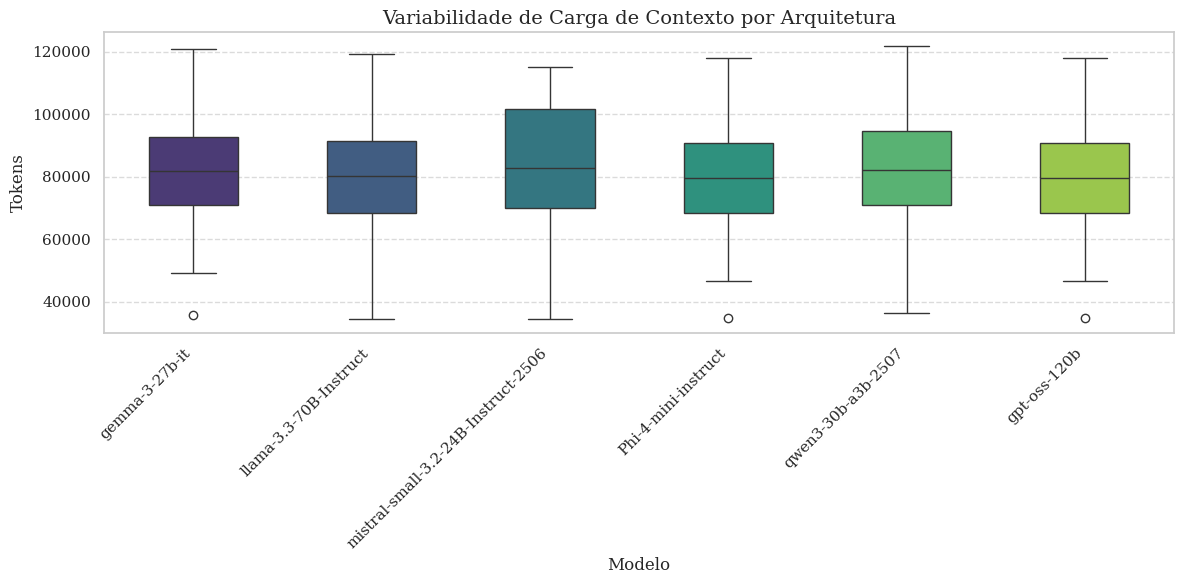

In [ ]:
cols_tokens = [c for c in table_count.columns if 'n_tokens_' in c]
df_melted = table_count.melt(id_vars=['title'], value_vars=cols_tokens, 
                             var_name='Modelo', value_name='Tokens')

df_melted['Modelo'] = df_melted['Modelo'].str.replace('n_tokens_', '')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Modelo', y='Tokens', hue='Modelo', palette='viridis', width=0.5)
plt.xticks(rotation=45, ha='right')
plt.title('Variabilidade de Carga de Contexto por Arquitetura')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
# Sumário estatístico do dataset
cols_analise = ['word_count'] + cols_tokens

tabela_i = table_count[cols_analise].agg(['mean', 'std', 'min', 'max']).transpose()
tabela_i.columns = ['Média', 'Desvio Padrão', 'Mínimo', 'Máximo']
tabela_i.index = ['Palavras (Corpus)'] + [c.replace('n_tokens_', '') for c in cols_tokens]

display(tabela_i.round(3))

,Média,Desvio Padrão,Mínimo,Máximo
Palavras (Corpus),48854.733,12897.268,19703.0,73373.0
gemma-3-27b-it,81111.867,19417.319,35736.0,120768.0
llama-3.3-70B-Instruct,79389.533,19036.011,34583.0,119270.0
mistral-small-3.2-24B-Instruct-2506,83850.533,20075.886,34471.0,115094.0
Phi-4-mini-instruct,78799.233,18811.648,34731.0,118007.0
qwen3-30b-a3b-2507,82377.633,19755.513,36379.0,121758.0
gpt-oss-120b,78799.233,18811.648,34731.0,118007.0


In [13]:
# O fator de expansão é a razão entre Tokens e Palavras
expansao_data = {}
for col in cols_tokens:
    model_name = col.replace('n_tokens_', '')
    fator = table_count[col] / table_count['word_count']
    expansao_data[model_name] = fator.mean()

tabela_ii = pd.DataFrame.from_dict(expansao_data, orient='index', columns=['Fator de Expansão (Tokens/Palavra)'])
tabela_ii = tabela_ii.sort_values(by='Fator de Expansão (Tokens/Palavra)', ascending=False)

display(tabela_ii.round(3))

,Fator de Expansão (Tokens/Palavra)
mistral-small-3.2-24B-Instruct-2506,1.741
qwen3-30b-a3b-2507,1.716
gemma-3-27b-it,1.688
llama-3.3-70B-Instruct,1.649
Phi-4-mini-instruct,1.637
gpt-oss-120b,1.637


In [14]:
df_abstracts = pd.read_csv('../datasets/Abstracts_ORA.csv')

df_abstracts['division'] = df_abstracts['division'].str.strip()

display(df_abstracts.head(2))

,title,abstract,division,department
0,Niu_2025_Functional_Nanolayer_Dielectrics,Negatively charged dielectric films have signi...,MPLS,Materials
1,Brody_2025_Numerical_simulation_of,Hypersonic flight is an essential component of...,MPLS,Engineering Science


In [15]:
contagem_divisoes = df_abstracts['division'].value_counts()

nomes_completos = {
    'MPLS': 'MPLS (Mathematical, Physical and Life Sciences)',
    'MSD': 'MSD (Medical Sciences)',
    'SSD': 'SSD (Social Sciences)',
    'HUMS': 'HUMS (Humanities)'
}

labels = contagem_divisoes.index.tolist()
sizes = contagem_divisoes.values.tolist()
legend_labels = [nomes_completos.get(label, label) for label in labels]

print("Contagem extraída do CSV:")
print(contagem_divisoes)

Contagem extraída do CSV:
division
MPLS    16
MSD      9
HUMS     3
SSD      2
Name: count, dtype: int64


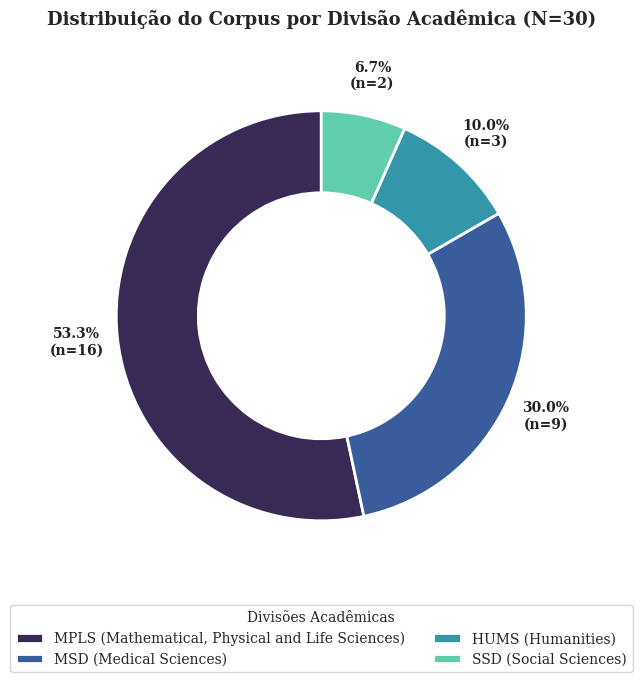

In [17]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',       
    'axes.titlesize': 13,         
    'axes.labelsize': 11,
    'legend.fontsize': 10
})

fig, ax = plt.subplots(figsize=(7, 7))

colors = sns.color_palette("mako", len(labels))

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n(n={val})'
    return my_format

wedges, texts, autotexts = ax.pie(
    sizes, 
    autopct=autopct_format(sizes),
    pctdistance=1.2,
    colors=colors, 
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='w', linewidth=2)
)

ax.legend(
    wedges, 
    legend_labels,
    title="Divisões Acadêmicas",
    title_fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.05), 
    ncol=2                       
)

plt.setp(autotexts, size=10, weight="bold", color="#222222")

total_n = sum(sizes)
ax.set_title(
    f"Distribuição do Corpus por Divisão Acadêmica (N={total_n})", 
    pad=25, 
    loc='center', 
    weight='bold'
)

plt.tight_layout()

plt.savefig('distribuicao_divisoes_academicas.pdf', bbox_inches='tight', dpi=300)

plt.show()